
--- Cluster 0 ---


,name,calories,sodium,alcohol,cost,cluster
0,Budweiser,144,15,4.7,0.43,0
1,Schlitz,151,19,4.9,0.43,0
5,Old_Milwaukee,145,23,4.6,0.28,0
6,Augsberger,175,24,5.5,0.40,0
7,Srohs_Bohemian_Style,149,27,4.7,0.42,0
10,Coors,140,18,4.6,0.44,0
16,Hamms,139,19,4.4,0.43,0
17,Heilemans_Old_Style,144,24,4.9,0.43,0



--- Cluster 1 ---


,name,calories,sodium,alcohol,cost,cluster
3,Kronenbourg,170,7,5.2,0.73,1
4,Heineken,152,11,5.0,0.77,1
13,Becks,150,19,4.7,0.76,1
14,Kirin,149,6,5.0,0.79,1



--- Cluster 2 ---


,name,calories,sodium,alcohol,cost,cluster
2,Lowenbrau,157,15,0.9,0.48,2
8,Miller_Lite,99,10,4.3,0.43,2
9,Budweiser_Light,113,8,3.7,0.40,2
11,Coors_Light,102,15,4.1,0.46,2
12,Michelob_Light,135,11,4.2,0.50,2
15,Pabst_Extra_Light,68,15,2.3,0.38,2
18,Olympia_Goled_Light,72,6,2.9,0.46,2
19,Schlitz_Light,97,7,4.2,0.47,2


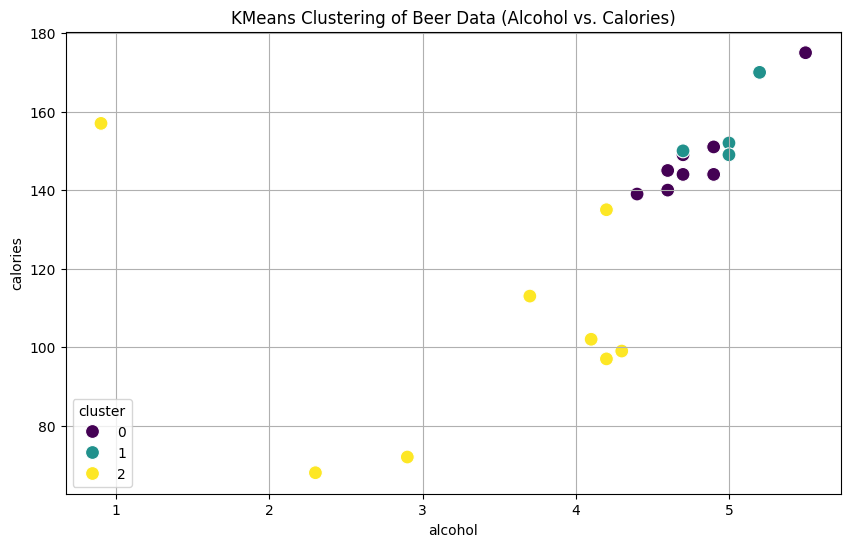

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# 1. Load data and define the features we care about
beer_df = pd.read_csv('beer.csv')
features = ['calories', 'sodium', 'alcohol', 'cost']

# 2. Scale the data and apply KMeans in one streamlined flow
scaled_data = StandardScaler().fit_transform(beer_df[features])
beer_df['cluster'] = KMeans(n_clusters=3, random_state=0, n_init='auto').fit_predict(scaled_data)

# 3. Display the items in each cluster (using list comprehension for brevity)
for i in range(3):
    print(f"\n--- Cluster {i} ---")
    display(beer_df[beer_df['cluster'] == i])

# 4. Visualize the clusters
plt.figure(figsize=(10, 6))
sns.scatterplot(data=beer_df, x='alcohol', y='calories', hue='cluster', palette='viridis', s=100)
plt.title('KMeans Clustering of Beer Data (Alcohol vs. Calories)')
plt.grid(True)
plt.show()